<a href="https://colab.research.google.com/github/Owusuatta/Course-Dash-Board-App/blob/main/Flight_data_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Downloading the data set from kaggle

In [3]:
!pip install opendatasets --upgrade

In [4]:
import opendatasets as od
od.version()

'0.1.22'

In [5]:
dateset_url ='https://www.kaggle.com/datasets/hrishitpatil/flight-data-2024'

In [6]:
od.download(dateset_url)

Skipping, found downloaded files in "./flight-data-2024" (use force=True to force download)


In [7]:
#checking the folder
import os
os.listdir('./flight-data-2024')
train_csv = './flight-data-2024/flight_data.csv'

In [8]:
#Loading the dataset using Pandas
%pip install pandas
import pandas as pd
flight_df = pd.read_csv('./flight-data-2024/flight_data_2024.csv')
display(flight_df.head())

/tmp/ipython-input-307344385.py:4: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  flight_df = pd.read_csv('./flight-data-2024/flight_data_2024.csv')


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


In [9]:
flight_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 35 columns):
 #   Column               Dtype  
---  ------               -----  
 0   year                 int64  
 1   month                int64  
 2   day_of_month         int64  
 3   day_of_week          int64  
 4   fl_date              object 
 5   op_unique_carrier    object 
 6   op_carrier_fl_num    float64
 7   origin               object 
 8   origin_city_name     object 
 9   origin_state_nm      object 
 10  dest                 object 
 11  dest_city_name       object 
 12  dest_state_nm        object 
 13  crs_dep_time         int64  
 14  dep_time             float64
 15  dep_delay            float64
 16  taxi_out             float64
 17  wheels_off           float64
 18  wheels_on            float64
 19  taxi_in              float64
 20  crs_arr_time         int64  
 21  arr_time             float64
 22  arr_delay            float64
 23  cancelled            int64  
 24

In [10]:
flight_df.describe()

,year,month,day_of_month,day_of_week,op_carrier_fl_num,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,7079081.0,7.079081e+06,7.079081e+06,7.079081e+06,7.079080e+06,7.079081e+06,6.986422e+06,6.986111e+06,6.983347e+06,6.983347e+06,...,7.079081e+06,7.079080e+06,6.965267e+06,6.965267e+06,7.079081e+06,7.079081e+06,7.079081e+06,7.079081e+06,7.079081e+06,7.079081e+06
mean,2024.0,6.584868e+00,1.578445e+01,3.981945e+00,2.504623e+03,1.327300e+03,1.330765e+03,1.267708e+01,1.790445e+01,1.353542e+03,...,2.471931e-03,1.467665e+02,1.412151e+02,1.149997e+02,8.339062e+02,5.060440e+00,8.752369e-01,2.771828e+00,2.541686e-02,5.929302e+00
std,0.0,3.396806e+00,8.786433e+00,2.012279e+00,1.652253e+03,4.930306e+02,5.094779e+02,5.605997e+01,9.677410e+00,5.120475e+02,...,4.965703e-02,7.238692e+01,7.230781e+01,7.036955e+01,5.962536e+02,3.572703e+01,1.542974e+01,1.546485e+01,1.422602e+00,3.106135e+01
min,2024.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.600000e+01,1.000000e+00,1.000000e+00,...,0.000000e+00,-1.600000e+02,1.500000e+01,5.000000e+00,1.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2024.0,4.000000e+00,8.000000e+00,2.000000e+00,1.151000e+03,9.050000e+02,9.080000e+02,-6.000000e+00,1.200000e+01,9.240000e+02,...,0.000000e+00,9.300000e+01,8.800000e+01,6.300000e+01,3.990000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2024.0,7.000000e+00,1.600000e+01,4.000000e+00,2.227000e+03,1.320000e+03,1.325000e+03,-2.000000e+00,1.500000e+01,1.338000e+03,...,0.000000e+00,1.300000e+02,1.250000e+02,9.800000e+01,6.800000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2024.0,1.000000e+01,2.300000e+01,6.000000e+00,3.717000e+03,1.736000e+03,1.746000e+03,9.000000e+00,2.100000e+01,1.801000e+03,...,0.000000e+00,1.770000e+02,1.720000e+02,1.450000e+02,1.069000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2024.0,1.200000e+01,3.100000e+01,7.000000e+00,8.819000e+03,2.400000e+03,2.400000e+03,3.777000e+03,2.140000e+02,2.400000e+03,...,1.000000e+00,1.326000e+03,7.920000e+02,7.230000e+02,5.095000e+03,3.689000e+03,1.804000e+03,2.700000e+03,1.164000e+03,2.690000e+03


In [11]:
flight_df.shape

(7079081, 35)

In [12]:
flight_df.columns

Index(['year', 'month', 'day_of_month', 'day_of_week', 'fl_date',
       'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name',
       'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm',
       'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off',
       'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay',
       'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time',
       'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay',
       'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [13]:
flight_df.isnull().sum()

,0
year,0
month,0
day_of_month,0
day_of_week,0
fl_date,0
op_unique_carrier,0
op_carrier_fl_num,1
origin,0
origin_city_name,0
origin_state_nm,0


In [14]:
#DATA ANALYSIS AND VISUALIZATION

In [15]:
!pip install plotly matplotlib seaborn

import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# For inline plots (in Jupyter)
%matplotlib inline

sns.set_style('darkgrid')

# Correct rcParams usage
matplotlib.rcParams['font.size'] = 24
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'


In [16]:
import plotly.express as px

px.bar(
    flight_df.groupby('month', as_index=False)['fl_date'].count(),
    x='month',
    y='fl_date',
    title='Monthly Flight Volume',
    labels={'fl_date': 'Number of Flights', 'month': 'Month'},
    color='month'
)


In [17]:
px.bar(
    flight_df.groupby('day_of_week', as_index=False)['fl_date'].count(),
    x='day_of_week',
    y='fl_date',
    color='day_of_week',
    title='Flights by Day of Week',
    labels={'fl_date': 'Number of Flights', 'day_of_week': 'Day of Week'}
)


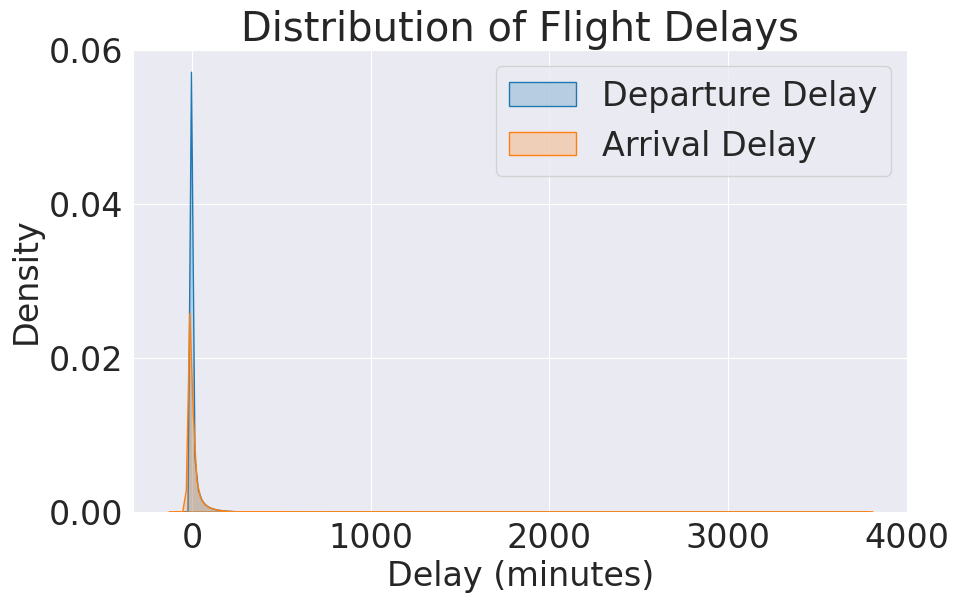

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.kdeplot(flight_df['dep_delay'], label='Departure Delay', fill=True)
sns.kdeplot(flight_df['arr_delay'], label='Arrival Delay', fill=True)
plt.title('Distribution of Flight Delays')
plt.xlabel('Delay (minutes)')
plt.legend()
plt.show()


In [19]:
top_origin = flight_df['origin_city_name'].value_counts().head(10).reset_index()
top_origin.columns = ['origin_city_name', 'flights']

px.bar(
    top_origin,
    x='origin_city_name',
    y='flights',
    title='Top 10 Origin Cities by Flight Count',
    color='flights'
)


In [21]:
flight_df['fl_date'] = pd.to_datetime(flight_df['fl_date'])
avg_delay = flight_df.groupby('fl_date', as_index=False)['arr_delay'].mean()

px.line(
    avg_delay,
    x='fl_date',
    y='arr_delay',
    title='Average Arrival Delay Over Time'
)


In [22]:
cancel_counts = flight_df['cancellation_code'].value_counts().reset_index()
cancel_counts.columns = ['cancellation_code', 'count']

px.pie(
    cancel_counts,
    names='cancellation_code',
    values='count',
    title='Reasons for Flight Cancellations'
)


In [23]:
#Training,Validation and Test set

In [24]:
from sklearn.model_selection import train_test_split

# Split into training + testing sets (80% train_val, 20% test)
train_val_df, test_df = train_test_split(
    flight_df, test_size=0.2, random_state=42
)

# Split train_val into training + validation sets
train_df, val_df = train_test_split(
    train_val_df, test_size=0.25, random_state=42
)

print('train_df.shape =', train_df.shape)
print('val_df.shape   =', val_df.shape)
print('test_df.shape  =', test_df.shape)


train_df.shape = (4247448, 35)
val_df.shape   = (1415816, 35)
test_df.shape  = (1415817, 35)


In [25]:
flight_df.columns


Index(['year', 'month', 'day_of_month', 'day_of_week', 'fl_date',
       'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name',
       'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm',
       'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off',
       'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay',
       'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time',
       'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay',
       'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [26]:
flight_df['fl_date'] = pd.to_datetime(flight_df['fl_date'])
flight_df['month'] = flight_df['fl_date'].dt.month
flight_df['month'].unique()


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

/tmp/ipython-input-4025376998.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




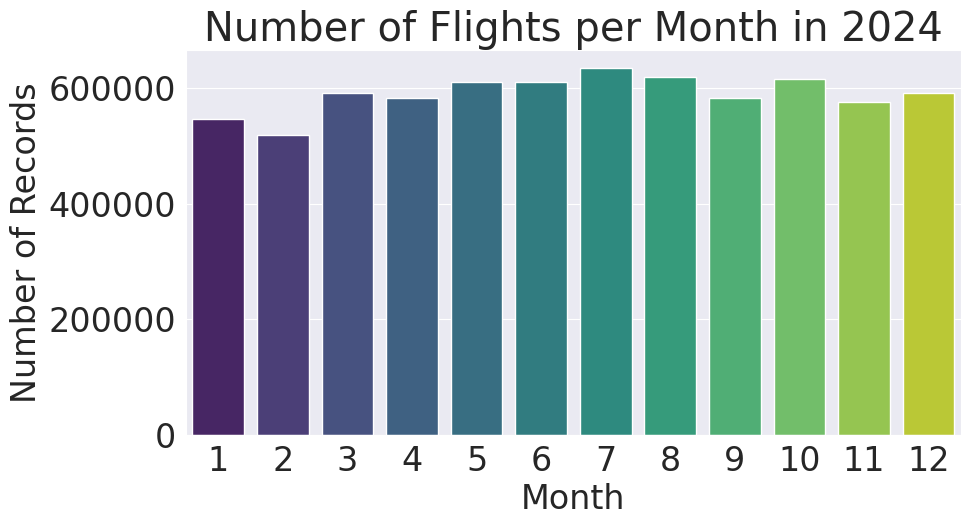

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.countplot(x='month', data=flight_df, palette='viridis')
plt.title('Number of Flights per Month in 2024')
plt.xlabel('Month')
plt.ylabel('Number of Records')
plt.show()


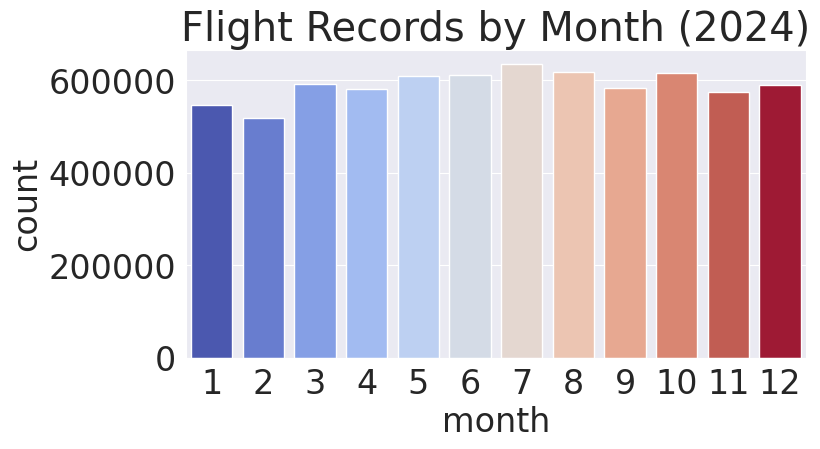

In [28]:
plt.figure(figsize=(8,4))
sns.countplot(x='month', hue='month', data=flight_df, palette='coolwarm', legend=False)
plt.title('Flight Records by Month (2024)')
plt.show()


In [29]:
import pandas as pd

# Convert to datetime if not already
flight_df['fl_date'] = pd.to_datetime(flight_df['fl_date'])

# Extract month
flight_df['month'] = flight_df['fl_date'].dt.month

# Quick check
print(flight_df['month'].unique())


[ 1  2  3  4  5  6  7  8  9 10 11 12]


In [30]:
#Training, validation and testing


from sklearn.model_selection import train_test_split

# Train = months 1–9
train_df = flight_df[flight_df['month'].isin(range(1, 10))]

# Validation = month 10
val_df = flight_df[flight_df['month'] == 10]

# Test = months 11–12
test_df = flight_df[flight_df['month'].isin([11, 12])]

# Check sizes
print('train_df.shape:', train_df.shape)
print('val_df.shape:', val_df.shape)
print('test_df.shape:', test_df.shape)


train_df.shape: (5297599, 35)
val_df.shape: (615497, 35)
test_df.shape: (1165985, 35)


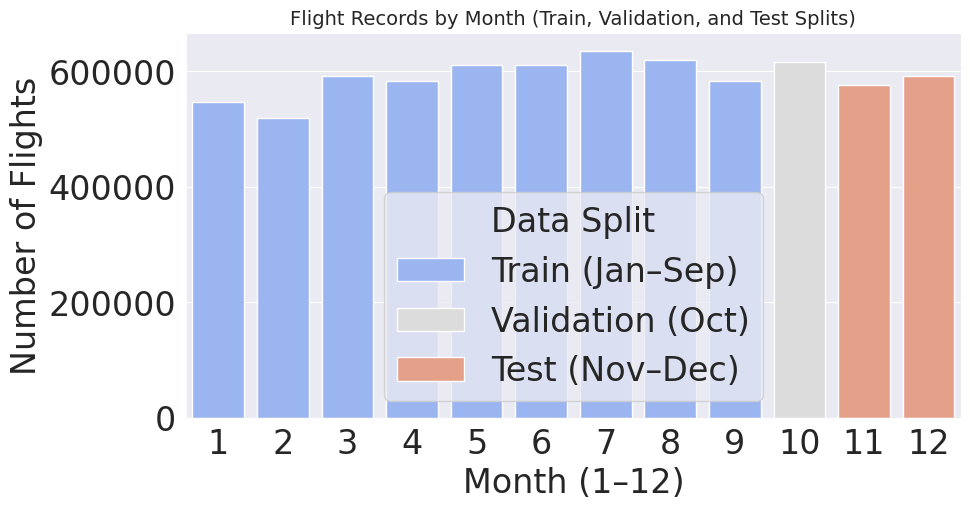

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Add a column to mark which split each row belongs to
def assign_split(month):
    if month in range(1, 10):
        return 'Train (Jan–Sep)'
    elif month == 10:
        return 'Validation (Oct)'
    else:
        return 'Test (Nov–Dec)'

flight_df['data_split'] = flight_df['month'].apply(assign_split)

# Plot with split color coding
plt.figure(figsize=(10, 5))
sns.countplot(x='month', hue='data_split', data=flight_df, palette='coolwarm')
plt.title('Flight Records by Month (Train, Validation, and Test Splits)', fontsize=14)
plt.xlabel('Month (1–12)')
plt.ylabel('Number of Flights')
plt.legend(title='Data Split')
plt.show()


In [33]:
#identifying input and target columns
# Select all columns except the first and last
input_cols = list(train_df.columns)[1:-1]

# Define your target column — e.g., predicting arrival delay
target_col = 'arr_delay'  # or 'is_delayed' if you created that earlier

print("Input columns:", input_cols)
print("Target column:", target_col)


Input columns: ['month', 'day_of_month', 'day_of_week', 'fl_date', 'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm', 'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay', 'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay']
Target column: arr_delay


In [34]:
X_train = train_df[input_cols]
y_train = train_df[target_col]

X_val = val_df[input_cols]
y_val = val_df[target_col]

X_test = test_df[input_cols]
y_test = test_df[target_col]


In [ ]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


In [ ]:
#convect the You should focus on:

#Understanding what numeric vs categorical columns mean.

#Knowing that models only work with numbers, so text must be encoded.

#Using this pipeline approach, because it automates preprocessing.

!pip install numpy
import numpy as np


In [35]:
import numpy as np

# Identify which columns are numeric and which are categorical
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['month', 'day_of_month', 'day_of_week', 'op_carrier_fl_num', 'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay', 'cancelled', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay']
Categorical columns: ['op_unique_carrier', 'origin', 'origin_city_name', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm', 'cancellation_code']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define preprocessing for numeric and categorical features
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),  # normalize numbers
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)  # encode text
])


In [ ]:
y_train.isnull().sum()


In [ ]:
train_df = train_df.dropna(subset=['arr_delay'])
val_df = val_df.dropna(subset=['arr_delay'])
test_df = test_df.dropna(subset=['arr_delay'])

X_train = train_df[input_cols]
y_train = train_df[target_col]

X_val = val_df[input_cols]
y_val = val_df[target_col]


In [ ]:
# Get summary statistics for numeric columns
train_df.describe()


In [ ]:
numeric_cols = train_df.select_dtypes(include='number').columns
train_df[numeric_cols].describe()


In [ ]:
train_df.isnull().sum().sort_values(ascending=False).head(20)


In [ ]:
# Fill missing values for all categorical columns with 'None'
categorical_cols = ['op_unique_carrier', 'origin', 'origin_city_name',
                    'origin_state_nm', 'dest', 'dest_city_name',
                    'dest_state_nm', 'cancellation_code']

for df in [train_df, val_df, test_df]:
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')

# Fill missing values for numeric columns with mean
numeric_cols = ['op_carrier_fl_num']  # You can add more numeric columns here if needed

for df in [train_df, val_df, test_df]:
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mean())


In [ ]:
train_df['arr_delay'].isnull().sum()



In [ ]:
train_df = train_df.dropna(subset=['arr_delay'])



In [ ]:
#imputing missing numeric data
from sklearn.impute import SimpleImputer
import numpy as np

# Select numeric columns
numeric_cols = train_df.select_dtypes(include=np.number).columns

# Create the imputer
imputer = SimpleImputer(strategy='mean')

# Fit on training data and transform train, val, and test sets
train_df[numeric_cols] = imputer.fit_transform(train_df[numeric_cols])
val_df[numeric_cols] = imputer.transform(val_df[numeric_cols])
test_df[numeric_cols] = imputer.transform(test_df[numeric_cols])


In [ ]:
train_df.head()


In [ ]:
train_df.isnull().sum().sort_values(ascending=False).head(10)


In [ ]:
print("✅ Checking variables:")
print("X_train:", 'OK' if 'X_train' in locals() else 'Missing')
print("y_train:", 'OK' if 'y_train' in locals() else 'Missing')
print("numeric_cols:", 'OK' if 'numeric_cols' in locals() else 'Missing')
print("categorical_cols:", 'OK' if 'categorical_cols' in locals() else 'Missing')


In [ ]:
# Define target and input columns
target_col = 'arr_delay'
input_cols = [col for col in flight_df.columns if col != target_col]

# Quick check
print("Target column:", target_col)
print("Number of input columns:", len(input_cols))
print("Sample input columns:", input_cols[:10])


In [ ]:
# Split features (X) and target (y)

# Remove 'data_split' from input_cols if it exists, as it was added after the split
if 'data_split' in input_cols:
    input_cols.remove('data_split')

X_train = train_df[input_cols]
y_train = train_df[target_col]

X_val = val_df[input_cols]
y_val = val_df[target_col]

X_test = test_df[input_cols]
y_test = test_df[target_col]


print("✅ Data split complete:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

In [ ]:
# 🧹 Fix mixed-type categorical columns
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)
    X_test[col] = X_test[col].astype(str)

print("✅ All categorical columns converted to string type.")


In [ ]:
X_train.loc[:, col] = X_train[col].astype(str)
X_val.loc[:, col] = X_val[col].astype(str)
X_test.loc[:, col] = X_test[col].astype(str)



In [ ]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns


In [ ]:
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))


In [ ]:
#preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing for numeric and categorical columns
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Combine transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)


In [ ]:
#create model pipeline
from sklearn.ensemble import RandomForestRegressor

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])


In [ ]:
!pip install pyarrow --quiet



In [ ]:
# Apply preprocessing to the datasets
train_inputs = preprocessor.fit_transform(X_train)
val_inputs = preprocessor.transform(X_val)
test_inputs = preprocessor.transform(X_test)

# Convert to DataFrames if needed (optional, depending on how you want to save)
# train_inputs_df = pd.DataFrame(train_inputs)
# val_inputs_df = pd.DataFrame(val_inputs)
# test_inputs_df = pd.DataFrame(test_inputs)

# Save the processed data
# If you want to save as DataFrames, use the lines above and uncomment the lines below
# train_inputs_df.to_parquet('train_inputs.parquet')
# val_inputs_df.to_parquet('val_inputs.parquet') # Changed from train_targets to val_inputs
# test_inputs_df.to_parquet('test_inputs.parquet')

# If you prefer to save as numpy arrays, you can use np.save
np.save('train_inputs.npy', train_inputs)
np.save('val_inputs.npy', val_inputs) # Changed from train_targets to val_inputs
np.save('test_inputs.npy', test_inputs)

print("Processed data saved to .npy files.")